In [1]:
filepath = r'C:\Users\User\Online_retail_analysis\Online_Retail_csv.csv'

import pandas as pd
import numpy as np
from scipy.stats import iqr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sqlite3

df = pd.read_csv(filepath)


In [2]:
print(df.columns)

Index(['Unnamed: 0', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [3]:
def clean_stockcode(df)->dict:
    clean_df = df[['StockCode','UnitPrice']].dropna()
    clean_df = df[df['UnitPrice'] > 0]
    global stock_prices_dict
    stock_prices_dict = dict(zip(clean_df.StockCode, clean_df.UnitPrice))
    
    return stock_prices_dict

df['UnitPrice'] = df.StockCode.map(clean_stockcode(df))


In [4]:
clean_description = df[df['Description'].notna() & df['Description'].str.isupper()]
stock_description_dict = dict(zip(clean_description.StockCode, clean_description.Description))

df['Description'] = df.StockCode.map(stock_description_dict)

In [5]:
df['date'] = pd.to_datetime(df.InvoiceDate, errors = 'coerce').dt.date
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')
df['date'] = df.date.dt.to_period('M')
df['Invoice_Date'] = df.date.astype('str')

df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(3)


In [6]:
print(df.date.min(), df.date.max())

2010-12 2011-12


In [7]:
df['Month'] = df['date'].dt.month

MONTHS = ('January','February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', \
'October', 'November', 'December')
months_keys = [i for i in range(1,13)]
months_dict = dict(zip(months_keys, MONTHS))

df['Month'] = df['date'].dt.month.map(months_dict)
df['Month'] = df.Month.astype('category')
df['Month'] = df['Month'].cat.set_categories(new_categories= MONTHS, ordered= True)

In [8]:
df.dropna(subset= 'UnitPrice', inplace = True)
df['log_scale'] = np.log1p(df.Revenue)

df_purchases = df[df['Revenue'] > 0]
df_returns = df[df['Revenue'] < 0]


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
faulty_purchases = df_purchases[df_purchases['log_scale'].abs() > 5]
faulty_returns = df_returns[df_returns['log_scale'].abs() > 3]

print(faulty_purchases.shape[0])
print(faulty_returns.shape[0])

15119
5


In [10]:
def outlier_filter(*series_1) -> tuple:
    '''Finds outlier for numerical Pandas Series of type float and int.
    Returns:
            Tuple(lower_bound, upper_bound) whereby lower bound can be found using oulier_filter('x')[0]
            and upper bound can be found using oulier_filter('x')[1]'''
    lower = np.quantile(series_1, 0.25)
    upper = np.quantile(series_1, 0.75)
    iqr = upper - lower
    lower_bound = lower - 1.5*iqr
    upper_bound = upper + 1.5*iqr
    return (lower_bound, upper_bound)


q1, q2 =  outlier_filter(df.loc[lambda x: x['Revenue'] > 0, ['Revenue']])
print(q1,q2)

-27.295000000000005 56.025000000000006


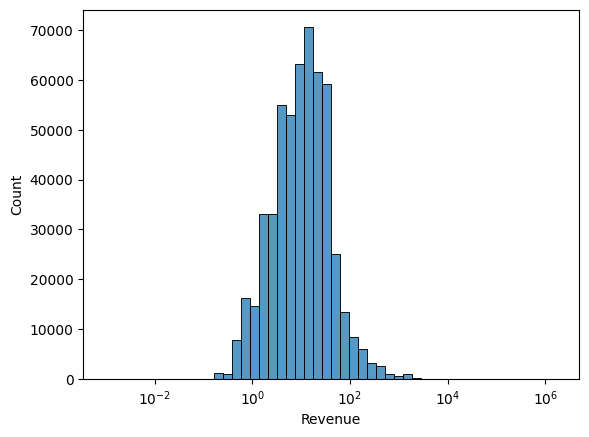

np.float64(623.6335044157536)

In [11]:
sns.histplot(df_purchases.Revenue, bins = 50, log_scale= True)
plt.show()
df_purchases.Revenue.skew()

In [12]:
def validating_false_revenue_positive():
    valid_df = df[np.logical_and(df['Quantity'] < 0, df['UnitPrice'] < 0)]
    print(valid_df.shape[0])

validating_false_revenue_positive()



0


In [13]:
#Do not delete, this validates that there is truly some StockCodes with missing UnitPrices thus making them a /
#unique values that need to be dropped. They are less than 300 though out of dataset of over 500K rows.

empty_prices = df[df.UnitPrice.isna()]
validation_list = []
for key, value in stock_prices_dict.items():
    if key in empty_prices.StockCode:
        validation_list.append(key)

print(len(validation_list))

0


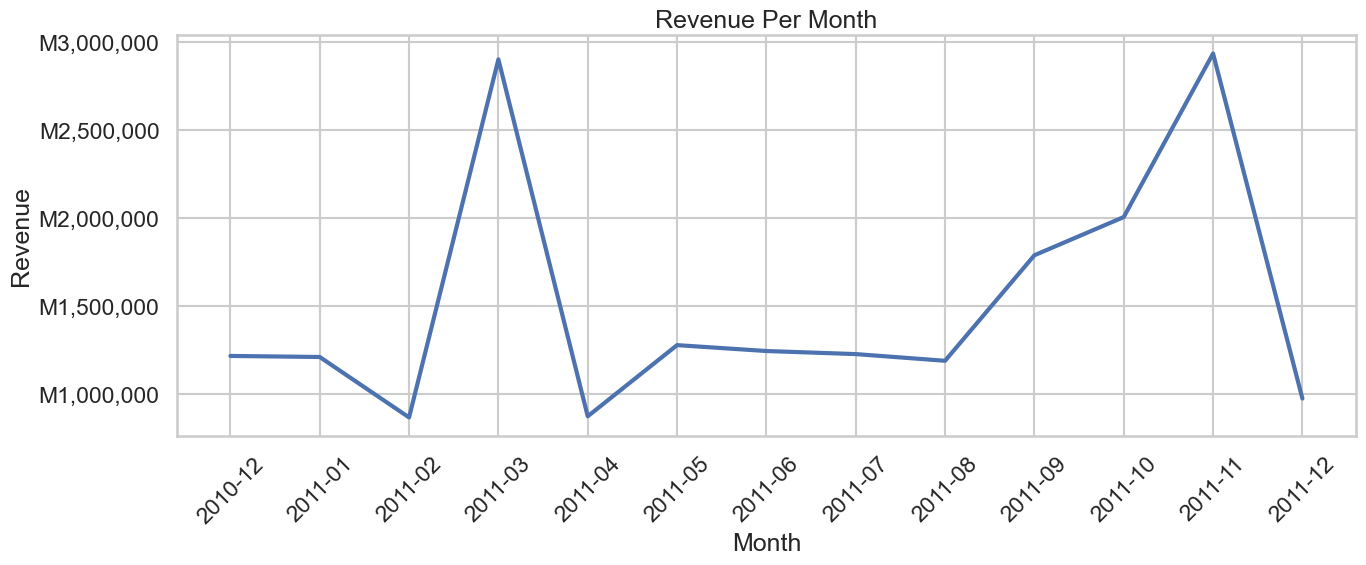

In [16]:
revenue_per_month = df_purchases.groupby('Invoice_Date')['Revenue'].sum().round(2).reset_index()
returns_per_month = df_returns.groupby('Invoice_Date')['Revenue'].sum().abs().round(2).reset_index()
def lineplot(Dataframe :pd.DataFrame, x: str, y: str, title: str, xlabel:  str, ylabel: str ):
    sns.set_theme(style= 'whitegrid', context= 'talk')
    plt.figure(figsize=(14,6))
    ax = sns.lineplot(data= Dataframe, x = x, y = y,
                    markers= 'o', linewidth = 3)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('M{x:,.0f}'))

    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

lineplot(revenue_per_month, 'Invoice_Date', 'Revenue', 'Revenue Per Month', 'Month', 'Revenue')
#lineplot(returns_per_month, 'Invoice_Date', 'Revenue', 'Returns Per Month', 'Month', 'Revenue')


In [ ]:
number_of_purchases_pm = df_purchases.value_counts('Invoice_Date').reset_index()
number_of_returns_pm = df_returns.value_counts('Invoice_Date').reset_index()
#print(number_of_returns_pm.head(13))

#print(df.loc[lambda x: x['Invoice_Date'] == '2011-03', ['Quantity']].describe())
march_dataset = df.loc[lambda x: x['Invoice_Date'] == '2011-03', :]
a, b = outlier_filter(march_dataset['Revenue'])
quantity_outliers = march_dataset[np.logical_or(march_dataset['Revenue'] < a, march_dataset['Revenue'] > b )]


In [ ]:
month_revenue = df.groupby('Month', observed= False)['Revenue'].sum().round(2).reset_index()

In [ ]:
unit_revenue = revenue_per_month.merge(right= number_of_purchases_pm, on= 'Invoice_Date', how = 'right')
unit_revenue['Unit_Revenue'] = round(unit_revenue.Revenue / unit_revenue['count'],2)
unit_revenue.head(14)

,Invoice_Date,Revenue,count,Unit_Revenue
0,2011-11,2933218.30,83497,35.13
1,2011-10,2004920.17,59394,33.76
2,2011-09,1788118.37,49322,36.25
3,2010-12,1216639.04,41670,29.20
4,2011-07,1227117.03,38715,31.70
5,2011-05,1277957.50,36292,35.21
6,2011-06,1244499.88,36056,34.52
7,2011-03,2900101.57,35915,80.75
8,2011-08,1189133.72,34566,34.40
9,2011-01,1210631.12,34350,35.24


In [ ]:
month_returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Month', 'Country'], observed= False)['Revenue'].sum().round(2).reset_index()

In [ ]:
#purchases no. per country
purchases_per_country = df.Country.value_counts().to_dict()
returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).reset_index()
returns_per_country_2 = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).to_dict()
countries_that_returned = list(returns_per_country.Country)
returns_per_purchases = returns_per_country.loc[lambda x: x['Country'] == countries_that_returned]

returns_per_purchases['UnitsSold'] = returns_per_purchases.Country.map(returns_per_country_2)

"""Reminder to find returns per country ratio. This is also retention rate"""

'Reminder to find returns per country ratio. This is also retention rate'